# SSL-Initialized Supervised Metric Learning

This notebook evaluates whether self-supervised handwriting pretraining provides a better initialization for supervised writer metric learning.

## Research question

The previous experiments established two complementary observations.

Self-supervised MoCo pretraining improved writer verification over the original ImageNet representation without using writer labels and produced a smaller within-versus-cross-script performance gap.

Supervised metric learning produced substantially stronger writer discrimination, while retaining a larger cross-script gap.

This experiment tests whether these properties can be combined.

## Controlled comparison

The supervised training protocol follows the writer-aware dynamic-sampling experiment.

The following components remain unchanged:

- Development-training writers only
- Arabic page 1 and page 2 supervised training pairs
- One genuine and one impostor pair per writer per epoch
- 226 genuine and 226 impostor pairs per epoch
- 10 deterministic negative-writer offsets across 10 epochs
- CosineEmbeddingLoss with margin 0.5
- ResNet-18 backbone
- Layer 4 trainable
- Earlier backbone layers frozen
- BatchNorm running statistics frozen
- Batch size 8
- AdamW optimization
- Validation ROC-AUC as the primary checkpoint-selection criterion
- EER used only as a tie-breaker
- Official-test writers excluded from model selection

## Experimental change

The only principal representation change is initialization.

Instead of initializing the ResNet-18 encoder directly from ImageNet, the backbone is initialized from the best epoch-20 self-supervised MoCo encoder from Notebook 13.

The MoCo projection head and queue are discarded.

Supervised writer metric learning operates directly on the 512-dimensional L2-normalized backbone embedding.

## Evaluation logic

The experiment will first evaluate the SSL-initialized encoder before supervised training.

It will then perform the same 10-epoch writer-aware dynamic metric-learning protocol.

The final comparisons will include:

- ImageNet initialization
- Standalone self-supervised representation
- ImageNet-initialized supervised metric learning
- SSL-initialized supervised metric learning

The central hypothesis is that self-supervised initialization may preserve more transferable handwriting structure while supervised metric learning adds writer discrimination.

A successful hybrid model should therefore improve writer-verification performance without increasing the cross-script generalization gap.

The official-test split will remain descriptive and will not be used for checkpoint or hyperparameter selection.

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, roc_curve
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision.models import ResNet18_Weights, resnet18

from handwriting_cross_script_research import (
    QUWIDataset,
    load_image_tensor,
)

In [2]:
SEED = 42
EPOCHS = 10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path.cwd().resolve()

while PROJECT_ROOT != PROJECT_ROOT.parent and not (
    PROJECT_ROOT / "pyproject.toml"
).exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

assert (
    PROJECT_ROOT
    / "pyproject.toml"
).exists()

IMAGE_DIR = (
    Path.home()
    / "Documents"
    / "Handwriting"
    / "QUWI"
    / "extracted"
    / "images"
)

SPLIT_PATH = (
    PROJECT_ROOT
    / "splits"
    / "quwi_writer_disjoint_split_seed42.csv"
)

VALIDATION_PAIR_PATH = (
    PROJECT_ROOT
    / "splits"
    / "verification"
    / "quwi_validation_verification_pairs.csv"
)

TEST_PAIR_PATH = (
    PROJECT_ROOT
    / "splits"
    / "verification"
    / "quwi_official_test_verification_pairs.csv"
)

SSL_CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "self_supervised_pretraining"
    / "resnet18_moco_ssl_best.pt"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "checkpoints"
    / "ssl_initialized_metric_learning"
)

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "ssl_initialized_metric_learning"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

split_df = pd.read_csv(
    SPLIT_PATH
)

development_df = (
    split_df[
        split_df[
            "experiment_split"
        ] == "development_train"
    ]
    .copy()
    .reset_index(drop=True)
)

validation_df = (
    split_df[
        split_df[
            "experiment_split"
        ] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    split_df[
        split_df[
            "experiment_split"
        ] == "official_test"
    ]
    .copy()
    .reset_index(drop=True)
)

validation_pairs_df = pd.read_csv(
    VALIDATION_PAIR_PATH
)

print(
    "Development images:",
    len(
        development_df
    ),
)

print(
    "Development writers:",
    development_df[
        "writer"
    ].nunique(),
)

print(
    "Validation writers:",
    validation_df[
        "writer"
    ].nunique(),
)

print(
    "Official-test writers:",
    test_df[
        "writer"
    ].nunique(),
)

print(
    "Validation pairs:",
    len(
        validation_pairs_df
    ),
)

print(
    "SSL checkpoint exists:",
    SSL_CHECKPOINT_PATH.exists(),
)

print(
    "Device:",
    DEVICE,
)

if DEVICE.type == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(
            0
        ),
    )

assert len(
    development_df
) == 904

assert development_df[
    "writer"
].nunique() == 226

assert validation_df[
    "writer"
].nunique() == 56

assert test_df[
    "writer"
].nunique() == 193

assert len(
    validation_pairs_df
) == 18_816

assert SSL_CHECKPOINT_PATH.exists()

Development images: 904
Development writers: 226
Validation writers: 56
Official-test writers: 193
Validation pairs: 18816
SSL checkpoint exists: True
Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
page1_df = (
    development_df[
        development_df[
            "page_id"
        ] == 1
    ]
    .sort_values(
        "writer"
    )
    .reset_index(drop=True)
)

page2_df = (
    development_df[
        development_df[
            "page_id"
        ] == 2
    ]
    .sort_values(
        "writer"
    )
    .reset_index(drop=True)
)

writers = (
    page1_df[
        "writer"
    ]
    .to_numpy()
)

assert np.array_equal(
    writers,
    page2_df[
        "writer"
    ].to_numpy(),
)

page1_filename = dict(
    zip(
        page1_df[
            "writer"
        ],
        page1_df[
            "filename"
        ],
    )
)

page2_filename = dict(
    zip(
        page2_df[
            "writer"
        ],
        page2_df[
            "filename"
        ],
    )
)

offset_rng = np.random.default_rng(
    SEED
)

epoch_offsets = offset_rng.choice(
    np.arange(
        1,
        len(
            writers
        ),
    ),
    size=EPOCHS,
    replace=False,
)

schedule_rows = []

for epoch, offset in enumerate(
    epoch_offsets,
    start=1,
):
    negative_indices = np.roll(
        np.arange(
            len(
                writers
            )
        ),
        -int(
            offset
        ),
    )

    epoch_rows = []

    for anchor_index, anchor_writer in enumerate(
        writers
    ):
        negative_writer = writers[
            negative_indices[
                anchor_index
            ]
        ]

        epoch_rows.append(
            {
                "epoch": epoch,
                "offset": int(
                    offset
                ),
                "anchor_writer": int(
                    anchor_writer
                ),
                "partner_writer": int(
                    anchor_writer
                ),
                "filename_a": page1_filename[
                    anchor_writer
                ],
                "filename_b": page2_filename[
                    anchor_writer
                ],
                "pair_label": 1,
            }
        )

        epoch_rows.append(
            {
                "epoch": epoch,
                "offset": int(
                    offset
                ),
                "anchor_writer": int(
                    anchor_writer
                ),
                "partner_writer": int(
                    negative_writer
                ),
                "filename_a": page1_filename[
                    anchor_writer
                ],
                "filename_b": page2_filename[
                    negative_writer
                ],
                "pair_label": 0,
            }
        )

    epoch_df = pd.DataFrame(
        epoch_rows
    ).sample(
        frac=1.0,
        random_state=(
            SEED
            + epoch
        ),
    )

    schedule_rows.append(
        epoch_df
    )

dynamic_training_pairs_df = pd.concat(
    schedule_rows,
    ignore_index=True,
)

epoch_pair_summary_df = (
    dynamic_training_pairs_df
    .groupby(
        [
            "epoch",
            "pair_label",
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

impostor_exposure_df = (
    dynamic_training_pairs_df[
        dynamic_training_pairs_df[
            "pair_label"
        ] == 0
    ]
    .groupby(
        "anchor_writer"
    )
    .agg(
        distinct_negative_writers=(
            "partner_writer",
            "nunique",
        ),
        total_negative_pairs=(
            "partner_writer",
            "size",
        ),
    )
    .reset_index()
)

self_impostor_pairs = (
    (
        dynamic_training_pairs_df[
            "pair_label"
        ] == 0
    )
    & (
        dynamic_training_pairs_df[
            "anchor_writer"
        ]
        == dynamic_training_pairs_df[
            "partner_writer"
        ]
    )
).sum()

print(
    "Epoch offsets:",
    epoch_offsets.tolist(),
)

print(
    "Total scheduled pairs:",
    len(
        dynamic_training_pairs_df
    ),
)

print(
    "Pairs per epoch:",
    dynamic_training_pairs_df
    .groupby(
        "epoch"
    )
    .size()
    .unique()
    .tolist(),
)

print(
    "Distinct negatives per anchor:",
    impostor_exposure_df[
        "distinct_negative_writers"
    ].unique().tolist(),
)

print(
    "Self-impostor pairs:",
    int(
        self_impostor_pairs
    ),
)

display(
    epoch_pair_summary_df
)

assert epoch_offsets.tolist() == [
    222,
    168,
    20,
    143,
    97,
    96,
    156,
    22,
    46,
    190,
]

assert len(
    dynamic_training_pairs_df
) == 4520

assert (
    dynamic_training_pairs_df
    .groupby(
        "epoch"
    )
    .size()
    == 452
).all()

assert (
    impostor_exposure_df[
        "distinct_negative_writers"
    ]
    == 10
).all()

assert self_impostor_pairs == 0

Epoch offsets: [222, 168, 20, 143, 97, 96, 156, 22, 46, 190]
Total scheduled pairs: 4520
Pairs per epoch: [452]
Distinct negatives per anchor: [10]
Self-impostor pairs: 0


pair_label,0,1
epoch,,
1,226,226
2,226,226
3,226,226
4,226,226
5,226,226
6,226,226
7,226,226
8,226,226
9,226,226


In [4]:
class QUWIPairDataset(Dataset):
    def __init__(
        self,
        pair_df,
        image_dir,
    ):
        self.pair_df = (
            pair_df
            .reset_index(drop=True)
            .copy()
        )

        self.image_dir = Path(
            image_dir
        )

    def __len__(self):
        return len(
            self.pair_df
        )

    def __getitem__(
        self,
        index,
    ):
        row = self.pair_df.iloc[
            index
        ]

        image_a, _ = load_image_tensor(
            self.image_dir
            / row[
                "filename_a"
            ]
        )

        image_b, _ = load_image_tensor(
            self.image_dir
            / row[
                "filename_b"
            ]
        )

        return {
            "image_a": image_a,
            "image_b": image_b,
            "pair_label": torch.tensor(
                row[
                    "pair_label"
                ],
                dtype=torch.float32,
            ),
            "filename_a": row[
                "filename_a"
            ],
            "filename_b": row[
                "filename_b"
            ],
        }


def create_epoch_loader(
    epoch,
):
    epoch_pairs_df = (
        dynamic_training_pairs_df[
            dynamic_training_pairs_df[
                "epoch"
            ] == epoch
        ]
        .reset_index(drop=True)
    )

    epoch_dataset = QUWIPairDataset(
        epoch_pairs_df,
        IMAGE_DIR,
    )

    generator = (
        torch.Generator()
        .manual_seed(
            SEED
            + epoch
        )
    )

    epoch_loader = DataLoader(
        epoch_dataset,
        batch_size=8,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        generator=generator,
    )

    return (
        epoch_pairs_df,
        epoch_dataset,
        epoch_loader,
    )


epoch1_pairs_df, epoch1_dataset, epoch1_loader = (
    create_epoch_loader(
        1
    )
)

epoch10_pairs_df, epoch10_dataset, epoch10_loader = (
    create_epoch_loader(
        10
    )
)

sample_batch = next(
    iter(
        epoch1_loader
    )
)

print(
    "Epoch-1 dataset:",
    len(
        epoch1_dataset
    ),
)

print(
    "Epoch-10 dataset:",
    len(
        epoch10_dataset
    ),
)

print(
    "Epoch-1 batches:",
    len(
        epoch1_loader
    ),
)

print(
    "Image-A shape:",
    sample_batch[
        "image_a"
    ].shape,
)

print(
    "Image-B shape:",
    sample_batch[
        "image_b"
    ].shape,
)

print(
    "Epoch-1 labels:",
    epoch1_pairs_df[
        "pair_label"
    ].value_counts().sort_index().to_dict(),
)

print(
    "Epoch-10 labels:",
    epoch10_pairs_df[
        "pair_label"
    ].value_counts().sort_index().to_dict(),
)

print(
    "Epoch-1 offset:",
    epoch1_pairs_df[
        "offset"
    ].unique().tolist(),
)

print(
    "Epoch-10 offset:",
    epoch10_pairs_df[
        "offset"
    ].unique().tolist(),
)

assert len(
    epoch1_dataset
) == 452

assert len(
    epoch10_dataset
) == 452

assert len(
    epoch1_loader
) == 57

assert sample_batch[
    "image_a"
].shape == (
    8,
    3,
    384,
    384,
)

assert sample_batch[
    "image_b"
].shape == (
    8,
    3,
    384,
    384,
)

assert epoch1_pairs_df[
    "pair_label"
].value_counts().to_dict() == {
    1: 226,
    0: 226,
}

Epoch-1 dataset: 452
Epoch-10 dataset: 452
Epoch-1 batches: 57
Image-A shape: torch.Size([8, 3, 384, 384])
Image-B shape: torch.Size([8, 3, 384, 384])
Epoch-1 labels: {0: 226, 1: 226}
Epoch-10 labels: {0: 226, 1: 226}
Epoch-1 offset: [222]
Epoch-10 offset: [190]


In [5]:
IMAGENET_MEAN = (
    0.485,
    0.456,
    0.406,
)

IMAGENET_STD = (
    0.229,
    0.224,
    0.225,
)

LOSS_MARGIN = 0.5


class MetricEmbeddingModel(nn.Module):
    def __init__(
        self,
    ):
        super().__init__()

        feature_extractor = resnet18(
            weights=None
        )

        feature_extractor.fc = (
            nn.Identity()
        )

        self.feature_extractor = (
            feature_extractor
        )

        self.register_buffer(
            "normalization_mean",
            torch.tensor(
                IMAGENET_MEAN
            ).view(
                1,
                3,
                1,
                1,
            ),
        )

        self.register_buffer(
            "normalization_std",
            torch.tensor(
                IMAGENET_STD
            ).view(
                1,
                3,
                1,
                1,
            ),
        )

        for parameter in (
            self
            .feature_extractor
            .parameters()
        ):
            parameter.requires_grad = False

        for parameter in (
            self
            .feature_extractor
            .layer4
            .parameters()
        ):
            parameter.requires_grad = True

    def train(
        self,
        mode=True,
    ):
        super().train(
            mode
        )

        self.feature_extractor.eval()

        return self

    def forward(
        self,
        images,
    ):
        images = (
            images
            - self.normalization_mean
        ) / self.normalization_std

        embeddings = (
            self.feature_extractor(
                images
            )
        )

        return F.normalize(
            embeddings,
            p=2,
            dim=1,
        )


ssl_checkpoint = torch.load(
    SSL_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

ssl_state_dict = (
    ssl_checkpoint[
        "model_state_dict"
    ]
)

backbone_prefix = (
    "encoder_q.backbone."
)

ssl_backbone_state_dict = {
    key[
        len(
            backbone_prefix
        ):
    ]: value
    for key, value
    in ssl_state_dict.items()
    if key.startswith(
        backbone_prefix
    )
}

metric_model = (
    MetricEmbeddingModel()
    .to(
        DEVICE
    )
)

load_result = (
    metric_model
    .feature_extractor
    .load_state_dict(
        ssl_backbone_state_dict,
        strict=True,
    )
)

criterion = nn.CosineEmbeddingLoss(
    margin=LOSS_MARGIN
)

optimizer = torch.optim.AdamW(
    metric_model
    .feature_extractor
    .layer4
    .parameters(),
    lr=1e-5,
    weight_decay=1e-4,
)

total_parameters = sum(
    parameter.numel()
    for parameter in (
        metric_model.parameters()
    )
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in (
        metric_model.parameters()
    )
    if parameter.requires_grad
)

frozen_parameters = (
    total_parameters
    - trainable_parameters
)

metric_model.train()

with torch.no_grad():
    sample_embeddings = (
        metric_model(
            sample_batch[
                "image_a"
            ].to(
                DEVICE
            )
        )
    )

print(
    "SSL source epoch:",
    ssl_checkpoint[
        "epoch"
    ],
)

print(
    "Loaded backbone tensors:",
    len(
        ssl_backbone_state_dict
    ),
)

print(
    "Missing keys:",
    load_result.missing_keys,
)

print(
    "Unexpected keys:",
    load_result.unexpected_keys,
)

print(
    "Total parameters:",
    total_parameters,
)

print(
    "Trainable parameters:",
    trainable_parameters,
)

print(
    "Frozen parameters:",
    frozen_parameters,
)

print(
    "Embedding shape:",
    sample_embeddings.shape,
)

print(
    "Mean embedding norm:",
    round(
        sample_embeddings.norm(
            dim=1
        ).mean().item(),
        6,
    ),
)

print(
    "Loss margin:",
    criterion.margin,
)

print(
    "Layer4 training flag:",
    metric_model
    .feature_extractor
    .layer4
    .training,
)

assert ssl_checkpoint[
    "epoch"
] == 20

assert len(
    load_result.missing_keys
) == 0

assert len(
    load_result.unexpected_keys
) == 0

assert trainable_parameters == 8_393_728

assert sample_embeddings.shape == (
    8,
    512,
)

assert np.isclose(
    sample_embeddings.norm(
        dim=1
    ).mean().item(),
    1.0,
    atol=1e-5,
)

assert (
    metric_model
    .feature_extractor
    .layer4
    .training
    is False
)

SSL source epoch: 20
Loaded backbone tensors: 120
Missing keys: []
Unexpected keys: []
Total parameters: 11176512
Trainable parameters: 8393728
Frozen parameters: 2782784
Embedding shape: torch.Size([8, 512])
Mean embedding norm: 1.0
Loss margin: 0.5
Layer4 training flag: False


In [6]:
metric_model.train()

optimizer.zero_grad(
    set_to_none=True
)

bn_layer = (
    metric_model
    .feature_extractor
    .layer4[0]
    .bn1
)

bn_running_mean_before = (
    bn_layer
    .running_mean
    .detach()
    .clone()
)

image_a = sample_batch[
    "image_a"
].to(
    DEVICE,
    non_blocking=True,
)

image_b = sample_batch[
    "image_b"
].to(
    DEVICE,
    non_blocking=True,
)

pair_labels = sample_batch[
    "pair_label"
].to(
    DEVICE,
    non_blocking=True,
)

targets = torch.where(
    pair_labels > 0.5,
    torch.ones_like(
        pair_labels
    ),
    -torch.ones_like(
        pair_labels
    ),
)

embedding_a = metric_model(
    image_a
)

embedding_b = metric_model(
    image_b
)

smoke_loss = criterion(
    embedding_a,
    embedding_b,
    targets,
)

smoke_loss.backward()

layer4_gradient_norm = (
    torch.nn.utils.clip_grad_norm_(
        metric_model
        .feature_extractor
        .layer4
        .parameters(),
        max_norm=5.0,
    )
)

early_backbone_gradients = sum(
    1
    for name, parameter in (
        metric_model
        .feature_extractor
        .named_parameters()
    )
    if not name.startswith(
        "layer4."
    )
    and parameter.grad is not None
)

finite_layer4_gradient = (
    torch.isfinite(
        layer4_gradient_norm
    ).item()
)

bn_running_mean_after = (
    bn_layer
    .running_mean
    .detach()
    .clone()
)

optimizer.zero_grad(
    set_to_none=True
)

print(
    "Smoke loss:",
    round(
        smoke_loss.item(),
        6,
    ),
)

print(
    "Layer4 gradient norm:",
    round(
        layer4_gradient_norm.item(),
        6,
    ),
)

print(
    "Finite layer4 gradient:",
    finite_layer4_gradient,
)

print(
    "Early-backbone parameters with gradients:",
    early_backbone_gradients,
)

print(
    "BatchNorm running mean unchanged:",
    torch.equal(
        bn_running_mean_before,
        bn_running_mean_after,
    ),
)

print(
    "Layer4 training flag:",
    metric_model
    .feature_extractor
    .layer4
    .training,
)

assert torch.isfinite(
    smoke_loss
)

assert layer4_gradient_norm.item() > 0

assert finite_layer4_gradient

assert early_backbone_gradients == 0

assert torch.equal(
    bn_running_mean_before,
    bn_running_mean_after,
)

assert (
    metric_model
    .feature_extractor
    .layer4
    .training
    is False
)

Smoke loss: 0.150701
Layer4 gradient norm: 1.952894
Finite layer4 gradient: True
Early-backbone parameters with gradients: 0
BatchNorm running mean unchanged: True
Layer4 training flag: False


In [7]:
validation_dataset = QUWIDataset(
    metadata=validation_df,
    image_dir=IMAGE_DIR,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)


@torch.inference_mode()
def extract_embeddings(
    model,
    loader,
):
    model.eval()

    filenames = []
    embedding_batches = []

    for batch in loader:
        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        embeddings = model(
            images
        )

        embedding_batches.append(
            embeddings.cpu()
        )

        filenames.extend(
            batch[
                "filename"
            ]
        )

    return (
        filenames,
        torch.cat(
            embedding_batches,
            dim=0,
        ),
    )


def score_pairs(
    pair_df,
    filenames,
    embeddings,
):
    filename_to_index = {
        filename: index
        for index, filename
        in enumerate(
            filenames
        )
    }

    indices_a = torch.tensor(
        [
            filename_to_index[
                filename
            ]
            for filename
            in pair_df[
                "filename_a"
            ]
        ],
        dtype=torch.long,
    )

    indices_b = torch.tensor(
        [
            filename_to_index[
                filename
            ]
            for filename
            in pair_df[
                "filename_b"
            ]
        ],
        dtype=torch.long,
    )

    scores = (
        embeddings[
            indices_a
        ]
        * embeddings[
            indices_b
        ]
    ).sum(
        dim=1
    )

    return scores.numpy()


def verification_metrics(
    labels,
    scores,
):
    labels = np.asarray(
        labels
    )

    scores = np.asarray(
        scores
    )

    auc = roc_auc_score(
        labels,
        scores,
    )

    fpr, tpr, thresholds = roc_curve(
        labels,
        scores,
        pos_label=1,
    )

    fnr = (
        1.0
        - tpr
    )

    difference = (
        fpr
        - fnr
    )

    eer = np.interp(
        0.0,
        difference,
        fpr,
    )

    eer_threshold = np.interp(
        0.0,
        difference,
        thresholds,
    )

    return {
        "roc_auc": float(
            auc
        ),
        "eer": float(
            eer
        ),
        "eer_percent": float(
            eer
            * 100
        ),
        "eer_threshold": float(
            eer_threshold
        ),
    }


epoch0_filenames, epoch0_embeddings = (
    extract_embeddings(
        metric_model,
        validation_loader,
    )
)

epoch0_scores = score_pairs(
    validation_pairs_df,
    epoch0_filenames,
    epoch0_embeddings,
)

epoch0_metrics = verification_metrics(
    validation_pairs_df[
        "pair_label"
    ].to_numpy(),
    epoch0_scores,
)

ssl_source_metrics = (
    ssl_checkpoint[
        "validation_metrics"
    ]
)

print(
    "Validation embeddings:",
    epoch0_embeddings.shape,
)

print(
    "Validation scores:",
    len(
        epoch0_scores
    ),
)

print(
    "SSL-initialized epoch-0 ROC-AUC:",
    round(
        epoch0_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "SSL-initialized epoch-0 EER:",
    round(
        epoch0_metrics[
            "eer_percent"
        ],
        4,
    ),
    "%",
)

print(
    "SSL-initialized epoch-0 EER threshold:",
    round(
        epoch0_metrics[
            "eer_threshold"
        ],
        6,
    ),
)

print(
    "Matches Notebook 13 AUC:",
    np.isclose(
        epoch0_metrics[
            "roc_auc"
        ],
        ssl_source_metrics[
            "roc_auc"
        ],
        atol=1e-8,
    ),
)

print(
    "Matches Notebook 13 EER:",
    np.isclose(
        epoch0_metrics[
            "eer_percent"
        ],
        ssl_source_metrics[
            "eer_percent"
        ],
        atol=1e-6,
    ),
)

print(
    "All embeddings finite:",
    torch.isfinite(
        epoch0_embeddings
    ).all().item(),
)

print(
    "All scores finite:",
    np.isfinite(
        epoch0_scores
    ).all(),
)

assert epoch0_embeddings.shape == (
    224,
    512,
)

assert len(
    epoch0_scores
) == 18_816

assert np.isclose(
    epoch0_metrics[
        "roc_auc"
    ],
    ssl_source_metrics[
        "roc_auc"
    ],
    atol=1e-8,
)

assert np.isclose(
    epoch0_metrics[
        "eer_percent"
    ],
    ssl_source_metrics[
        "eer_percent"
    ],
    atol=1e-6,
)

Validation embeddings: torch.Size([224, 512])
Validation scores: 18816
SSL-initialized epoch-0 ROC-AUC: 0.673769
SSL-initialized epoch-0 EER: 38.9881 %
SSL-initialized epoch-0 EER threshold: 0.694182
Matches Notebook 13 AUC: True
Matches Notebook 13 EER: True
All embeddings finite: True
All scores finite: True


In [8]:
MAX_GRAD_NORM = 5.0

BEST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "resnet18_ssl_initialized_dynamic_metric_best.pt"
)


def train_metric_epoch(
    model,
    loader,
    optimizer,
    criterion,
):
    model.train()

    total_loss = 0.0
    total_samples = 0

    genuine_similarities = []
    impostor_similarities = []
    gradient_norms = []

    skipped_steps = 0

    for batch in loader:
        image_a = batch[
            "image_a"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        image_b = batch[
            "image_b"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        pair_labels = batch[
            "pair_label"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        targets = torch.where(
            pair_labels > 0.5,
            torch.ones_like(
                pair_labels
            ),
            -torch.ones_like(
                pair_labels
            ),
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        embedding_a = model(
            image_a
        )

        embedding_b = model(
            image_b
        )

        loss = criterion(
            embedding_a,
            embedding_b,
            targets,
        )

        loss.backward()

        gradient_norm = (
            torch.nn.utils.clip_grad_norm_(
                model
                .feature_extractor
                .layer4
                .parameters(),
                max_norm=MAX_GRAD_NORM,
            )
        )

        if torch.isfinite(
            gradient_norm
        ):
            optimizer.step()
        else:
            skipped_steps += 1

        similarities = (
            embedding_a
            * embedding_b
        ).sum(
            dim=1
        )

        genuine_mask = (
            pair_labels > 0.5
        )

        impostor_mask = (
            pair_labels <= 0.5
        )

        genuine_similarities.extend(
            similarities[
                genuine_mask
            ]
            .detach()
            .cpu()
            .tolist()
        )

        impostor_similarities.extend(
            similarities[
                impostor_mask
            ]
            .detach()
            .cpu()
            .tolist()
        )

        gradient_norms.append(
            float(
                gradient_norm
                .detach()
                .cpu()
            )
        )

        batch_size = (
            image_a.shape[0]
        )

        total_loss += (
            loss.item()
            * batch_size
        )

        total_samples += batch_size

    genuine_mean = float(
        np.mean(
            genuine_similarities
        )
    )

    impostor_mean = float(
        np.mean(
            impostor_similarities
        )
    )

    return {
        "loss": float(
            total_loss
            / total_samples
        ),
        "genuine_similarity": genuine_mean,
        "impostor_similarity": impostor_mean,
        "similarity_gap": float(
            genuine_mean
            - impostor_mean
        ),
        "mean_gradient_norm": float(
            np.mean(
                gradient_norms
            )
        ),
        "max_gradient_norm": float(
            np.max(
                gradient_norms
            )
        ),
        "skipped_steps": int(
            skipped_steps
        ),
    }


def evaluate_validation(
    model,
):
    filenames, embeddings = (
        extract_embeddings(
            model,
            validation_loader,
        )
    )

    scores = score_pairs(
        validation_pairs_df,
        filenames,
        embeddings,
    )

    metrics = verification_metrics(
        validation_pairs_df[
            "pair_label"
        ].to_numpy(),
        scores,
    )

    return (
        metrics,
        embeddings,
        scores,
    )


torch.save(
    {
        "epoch": 0,
        "model_state_dict": (
            metric_model
            .state_dict()
        ),
        "optimizer_state_dict": (
            optimizer
            .state_dict()
        ),
        "validation_metrics": (
            epoch0_metrics
        ),
        "configuration": {
            "seed": SEED,
            "epochs": EPOCHS,
            "initialization": (
                "self_supervised_moco_epoch_20"
            ),
            "ssl_source_epoch": int(
                ssl_checkpoint[
                    "epoch"
                ]
            ),
            "sampling_strategy": (
                "dynamic_negative_writer"
            ),
            "distinct_negative_writers_per_anchor": 10,
            "epoch_offsets": (
                epoch_offsets.tolist()
            ),
            "loss": (
                "CosineEmbeddingLoss"
            ),
            "loss_margin": LOSS_MARGIN,
            "batch_size": 8,
            "learning_rate": 1e-5,
            "weight_decay": 1e-4,
            "max_gradient_norm": MAX_GRAD_NORM,
        },
    },
    BEST_CHECKPOINT_PATH,
)

print(
    "Epoch-0 checkpoint saved:",
    BEST_CHECKPOINT_PATH.exists(),
)

print(
    "Initialization:",
    "self_supervised_moco_epoch_20",
)

print(
    "Initial validation AUC:",
    round(
        epoch0_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Initial validation EER:",
    round(
        epoch0_metrics[
            "eer_percent"
        ],
        4,
    ),
    "%",
)

print(
    "Negative writers per anchor:",
    int(
        impostor_exposure_df[
            "distinct_negative_writers"
        ].iloc[0]
    ),
)

Epoch-0 checkpoint saved: True
Initialization: self_supervised_moco_epoch_20
Initial validation AUC: 0.673769
Initial validation EER: 38.9881 %
Negative writers per anchor: 10


In [9]:
history_rows = [
    {
        "epoch": 0,
        "offset": 0,
        "training_loss": np.nan,
        "genuine_similarity": np.nan,
        "impostor_similarity": np.nan,
        "similarity_gap": np.nan,
        "mean_gradient_norm": np.nan,
        "max_gradient_norm": np.nan,
        "skipped_steps": 0,
        "validation_roc_auc": (
            epoch0_metrics[
                "roc_auc"
            ]
        ),
        "validation_eer_percent": (
            epoch0_metrics[
                "eer_percent"
            ]
        ),
        "validation_eer_threshold": (
            epoch0_metrics[
                "eer_threshold"
            ]
        ),
    }
]

best_epoch = 0

best_validation_auc = (
    epoch0_metrics[
        "roc_auc"
    ]
)

best_validation_eer = (
    epoch0_metrics[
        "eer_percent"
    ]
)

for epoch in range(
    1,
    EPOCHS + 1,
):
    (
        epoch_pairs_df,
        epoch_dataset,
        epoch_loader,
    ) = create_epoch_loader(
        epoch
    )

    train_metrics = train_metric_epoch(
        metric_model,
        epoch_loader,
        optimizer,
        criterion,
    )

    (
        validation_metrics,
        _,
        _,
    ) = evaluate_validation(
        metric_model
    )

    current_offset = int(
        epoch_pairs_df[
            "offset"
        ].iloc[0]
    )

    history_rows.append(
        {
            "epoch": epoch,
            "offset": current_offset,
            "training_loss": train_metrics[
                "loss"
            ],
            "genuine_similarity": train_metrics[
                "genuine_similarity"
            ],
            "impostor_similarity": train_metrics[
                "impostor_similarity"
            ],
            "similarity_gap": train_metrics[
                "similarity_gap"
            ],
            "mean_gradient_norm": train_metrics[
                "mean_gradient_norm"
            ],
            "max_gradient_norm": train_metrics[
                "max_gradient_norm"
            ],
            "skipped_steps": train_metrics[
                "skipped_steps"
            ],
            "validation_roc_auc": validation_metrics[
                "roc_auc"
            ],
            "validation_eer_percent": validation_metrics[
                "eer_percent"
            ],
            "validation_eer_threshold": validation_metrics[
                "eer_threshold"
            ],
        }
    )

    auc_improved = (
        validation_metrics[
            "roc_auc"
        ]
        > best_validation_auc
        + 1e-12
    )

    auc_tied = np.isclose(
        validation_metrics[
            "roc_auc"
        ],
        best_validation_auc,
        atol=1e-12,
        rtol=0.0,
    )

    eer_improved_on_tie = (
        auc_tied
        and validation_metrics[
            "eer_percent"
        ]
        < best_validation_eer
    )

    if (
        auc_improved
        or eer_improved_on_tie
    ):
        best_epoch = epoch

        best_validation_auc = (
            validation_metrics[
                "roc_auc"
            ]
        )

        best_validation_eer = (
            validation_metrics[
                "eer_percent"
            ]
        )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": (
                    metric_model
                    .state_dict()
                ),
                "optimizer_state_dict": (
                    optimizer
                    .state_dict()
                ),
                "training_metrics": (
                    train_metrics
                ),
                "validation_metrics": (
                    validation_metrics
                ),
                "configuration": {
                    "seed": SEED,
                    "initialization": (
                        "self_supervised_moco_epoch_20"
                    ),
                    "ssl_source_epoch": int(
                        ssl_checkpoint[
                            "epoch"
                        ]
                    ),
                    "sampling_strategy": (
                        "dynamic_negative_writer"
                    ),
                    "distinct_negative_writers_per_anchor": 10,
                    "epoch_offset": current_offset,
                    "loss_margin": LOSS_MARGIN,
                    "batch_size": 8,
                    "learning_rate": 1e-5,
                    "weight_decay": 1e-4,
                    "max_gradient_norm": MAX_GRAD_NORM,
                },
            },
            BEST_CHECKPOINT_PATH,
        )

    print(
        f"Epoch {epoch:02d} | "
        f"offset {current_offset:03d} | "
        f"loss {train_metrics['loss']:.4f} | "
        f"genuine {train_metrics['genuine_similarity']:.4f} | "
        f"impostor {train_metrics['impostor_similarity']:.4f} | "
        f"gap {train_metrics['similarity_gap']:.4f} | "
        f"val AUC {validation_metrics['roc_auc']:.4f} | "
        f"val EER {validation_metrics['eer_percent']:.2f}% | "
        f"grad {train_metrics['mean_gradient_norm']:.4f} | "
        f"skipped {train_metrics['skipped_steps']}"
    )

training_history_df = pd.DataFrame(
    history_rows
)

print()
print(
    "Best epoch:",
    best_epoch,
)

print(
    "Best validation AUC:",
    round(
        best_validation_auc,
        6,
    ),
)

print(
    "Best validation EER:",
    round(
        best_validation_eer,
        4,
    ),
    "%",
)

print(
    "Best checkpoint exists:",
    BEST_CHECKPOINT_PATH.exists(),
)

print(
    "Total skipped optimizer steps:",
    int(
        training_history_df[
            "skipped_steps"
        ].sum()
    ),
)

print(
    "Gain over SSL initialization:",
    round(
        best_validation_auc
        - epoch0_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Difference vs ImageNet-initialized dynamic baseline:",
    round(
        best_validation_auc
        - 0.741935,
        6,
    ),
)

Epoch 01 | offset 222 | loss 0.1966 | genuine 0.7400 | impostor 0.6244 | gap 0.1155 | val AUC 0.7068 | val EER 35.80% | grad 1.8937 | skipped 0
Epoch 02 | offset 168 | loss 0.1778 | genuine 0.7648 | impostor 0.6072 | gap 0.1576 | val AUC 0.7210 | val EER 34.47% | grad 1.8492 | skipped 0
Epoch 03 | offset 020 | loss 0.1635 | genuine 0.7757 | impostor 0.5745 | gap 0.2011 | val AUC 0.7181 | val EER 35.12% | grad 2.0074 | skipped 0
Epoch 04 | offset 143 | loss 0.1516 | genuine 0.8108 | impostor 0.5874 | gap 0.2233 | val AUC 0.7349 | val EER 33.03% | grad 1.9700 | skipped 0
Epoch 05 | offset 097 | loss 0.1521 | genuine 0.8123 | impostor 0.5780 | gap 0.2343 | val AUC 0.7291 | val EER 33.63% | grad 2.0142 | skipped 0
Epoch 06 | offset 096 | loss 0.1390 | genuine 0.8072 | impostor 0.5319 | gap 0.2752 | val AUC 0.7382 | val EER 33.27% | grad 2.3423 | skipped 0
Epoch 07 | offset 156 | loss 0.1308 | genuine 0.8434 | impostor 0.5596 | gap 0.2838 | val AUC 0.7424 | val EER 33.33% | grad 2.1354 | sk

In [10]:
best_checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

best_hybrid_model = (
    MetricEmbeddingModel()
    .to(DEVICE)
)

best_hybrid_model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ],
    strict=True,
)

best_hybrid_model.eval()

(
    frozen_validation_metrics,
    frozen_validation_embeddings,
    frozen_validation_scores,
) = evaluate_validation(
    best_hybrid_model
)

test_pairs_df = pd.read_csv(
    TEST_PAIR_PATH
)

test_dataset = QUWIDataset(
    metadata=test_df,
    image_dir=IMAGE_DIR,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_filenames, test_embeddings = (
    extract_embeddings(
        best_hybrid_model,
        test_loader,
    )
)

test_scores = score_pairs(
    test_pairs_df,
    test_filenames,
    test_embeddings,
)

test_metrics = verification_metrics(
    test_pairs_df[
        "pair_label"
    ].to_numpy(),
    test_scores,
)

print(
    "Loaded checkpoint epoch:",
    best_checkpoint[
        "epoch"
    ],
)

print(
    "Validation embeddings:",
    frozen_validation_embeddings.shape,
)

print(
    "Official-test embeddings:",
    test_embeddings.shape,
)

print(
    "Frozen validation ROC-AUC:",
    round(
        frozen_validation_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Frozen validation EER:",
    round(
        frozen_validation_metrics[
            "eer_percent"
        ],
        4,
    ),
    "%",
)

print(
    "Official-test ROC-AUC:",
    round(
        test_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Official-test EER:",
    round(
        test_metrics[
            "eer_percent"
        ],
        4,
    ),
    "%",
)

print(
    "Validation scores finite:",
    np.isfinite(
        frozen_validation_scores
    ).all(),
)

print(
    "Official-test scores finite:",
    np.isfinite(
        test_scores
    ).all(),
)

assert best_checkpoint[
    "epoch"
] == 8

assert np.isclose(
    frozen_validation_metrics[
        "roc_auc"
    ],
    best_validation_auc,
    atol=1e-8,
)

assert np.isclose(
    frozen_validation_metrics[
        "eer_percent"
    ],
    best_validation_eer,
    atol=1e-6,
)

assert frozen_validation_embeddings.shape == (
    224,
    512,
)

assert test_embeddings.shape == (
    772,
    512,
)

assert len(
    frozen_validation_scores
) == 18_816

assert len(
    test_scores
) == 223_494

Loaded checkpoint epoch: 8
Validation embeddings: torch.Size([224, 512])
Official-test embeddings: torch.Size([772, 512])
Frozen validation ROC-AUC: 0.744147
Frozen validation EER: 32.9978 %
Official-test ROC-AUC: 0.766937
Official-test EER: 30.8812 %
Validation scores finite: True
Official-test scores finite: True


In [11]:
def evaluate_conditions(
    pair_df,
    scores,
    split_name,
):
    scored_df = pair_df.copy()

    scored_df[
        "hybrid_cosine_score"
    ] = scores

    rows = []

    aggregate_metrics = verification_metrics(
        scored_df[
            "pair_label"
        ].to_numpy(),
        scored_df[
            "hybrid_cosine_score"
        ].to_numpy(),
    )

    rows.append(
        {
            "experiment_split": split_name,
            "condition_id": "all_conditions",
            **aggregate_metrics,
        }
    )

    for condition_id, condition_df in scored_df.groupby(
        "condition_id",
        sort=False,
    ):
        metrics = verification_metrics(
            condition_df[
                "pair_label"
            ].to_numpy(),
            condition_df[
                "hybrid_cosine_score"
            ].to_numpy(),
        )

        rows.append(
            {
                "experiment_split": split_name,
                "condition_id": condition_id,
                **metrics,
            }
        )

    return pd.DataFrame(
        rows
    )


hybrid_condition_results_df = pd.concat(
    [
        evaluate_conditions(
            validation_pairs_df,
            frozen_validation_scores,
            "validation",
        ),
        evaluate_conditions(
            test_pairs_df,
            test_scores,
            "official_test",
        ),
    ],
    ignore_index=True,
)

DYNAMIC_RESULTS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "writer_aware_dynamic_sampling"
    / "verification_condition_results.csv"
)

dynamic_results_df = pd.read_csv(
    DYNAMIC_RESULTS_PATH
)

hybrid_dynamic_comparison_df = (
    dynamic_results_df[
        [
            "experiment_split",
            "condition_id",
            "roc_auc",
            "eer_percent",
        ]
    ]
    .merge(
        hybrid_condition_results_df[
            [
                "experiment_split",
                "condition_id",
                "roc_auc",
                "eer_percent",
            ]
        ],
        on=[
            "experiment_split",
            "condition_id",
        ],
        suffixes=(
            "_dynamic",
            "_hybrid",
        ),
    )
)

hybrid_dynamic_comparison_df[
    "auc_change"
] = (
    hybrid_dynamic_comparison_df[
        "roc_auc_hybrid"
    ]
    - hybrid_dynamic_comparison_df[
        "roc_auc_dynamic"
    ]
)

hybrid_dynamic_comparison_df[
    "eer_change_points"
] = (
    hybrid_dynamic_comparison_df[
        "eer_percent_hybrid"
    ]
    - hybrid_dynamic_comparison_df[
        "eer_percent_dynamic"
    ]
)

display(
    hybrid_dynamic_comparison_df.round(
        4
    )
)

condition_metadata_df = (
    validation_pairs_df[
        [
            "condition_id",
            "script_relation",
            "text_relation",
        ]
    ]
    .drop_duplicates()
)

condition_comparison_df = (
    hybrid_dynamic_comparison_df[
        hybrid_dynamic_comparison_df[
            "condition_id"
        ] != "all_conditions"
    ]
    .merge(
        condition_metadata_df,
        on="condition_id",
        how="left",
    )
)

condition_comparison_df[
    "script_family"
] = np.where(
    condition_comparison_df[
        "script_relation"
    ] == "cross_script",
    "cross_script",
    "within_script",
)

script_family_comparison_df = (
    condition_comparison_df
    .groupby(
        [
            "experiment_split",
            "script_family",
        ],
        as_index=False,
    )
    .agg(
        conditions=(
            "condition_id",
            "nunique",
        ),
        dynamic_auc=(
            "roc_auc_dynamic",
            "mean",
        ),
        hybrid_auc=(
            "roc_auc_hybrid",
            "mean",
        ),
        dynamic_eer=(
            "eer_percent_dynamic",
            "mean",
        ),
        hybrid_eer=(
            "eer_percent_hybrid",
            "mean",
        ),
    )
)

script_family_comparison_df[
    "auc_change"
] = (
    script_family_comparison_df[
        "hybrid_auc"
    ]
    - script_family_comparison_df[
        "dynamic_auc"
    ]
)

script_family_comparison_df[
    "eer_change_points"
] = (
    script_family_comparison_df[
        "hybrid_eer"
    ]
    - script_family_comparison_df[
        "dynamic_eer"
    ]
)

display(
    script_family_comparison_df.round(
        4
    )
)

for split_name in [
    "validation",
    "official_test",
]:
    split_rows = (
        script_family_comparison_df[
            script_family_comparison_df[
                "experiment_split"
            ] == split_name
        ]
    )

    within_row = split_rows[
        split_rows[
            "script_family"
        ] == "within_script"
    ].iloc[0]

    cross_row = split_rows[
        split_rows[
            "script_family"
        ] == "cross_script"
    ].iloc[0]

    dynamic_gap = (
        within_row[
            "dynamic_auc"
        ]
        - cross_row[
            "dynamic_auc"
        ]
    )

    hybrid_gap = (
        within_row[
            "hybrid_auc"
        ]
        - cross_row[
            "hybrid_auc"
        ]
    )

    print()
    print(
        split_name,
        "within-script AUC change:",
        round(
            within_row[
                "auc_change"
            ],
            4,
        ),
    )

    print(
        split_name,
        "cross-script AUC change:",
        round(
            cross_row[
                "auc_change"
            ],
            4,
        ),
    )

    print(
        split_name,
        "dynamic script gap:",
        round(
            dynamic_gap,
            4,
        ),
    )

    print(
        split_name,
        "hybrid script gap:",
        round(
            hybrid_gap,
            4,
        ),
    )

condition_only_df = (
    hybrid_dynamic_comparison_df[
        hybrid_dynamic_comparison_df[
            "condition_id"
        ] != "all_conditions"
    ]
)

print()
print(
    "Hybrid improved condition AUC:",
    int(
        (
            condition_only_df[
                "auc_change"
            ] > 0
        ).sum()
    ),
    "of",
    len(
        condition_only_df
    ),
)

print(
    "Hybrid reduced condition EER:",
    int(
        (
            condition_only_df[
                "eer_change_points"
            ] < 0
        ).sum()
    ),
    "of",
    len(
        condition_only_df
    ),
)

assert len(
    hybrid_condition_results_df
) == 14

assert len(
    hybrid_dynamic_comparison_df
) == 14

,experiment_split,condition_id,roc_auc_dynamic,eer_percent_dynamic,roc_auc_hybrid,eer_percent_hybrid,auc_change,eer_change_points
0,validation,all_conditions,0.7419,32.7327,0.7441,32.9978,0.0022,0.2652
1,validation,arabic_variable_same,0.8543,21.7857,0.8748,20.0649,0.0205,-1.7208
2,validation,english_variable_same,0.8084,25.8442,0.8300,23.9286,0.0217,-1.9156
3,validation,cross_variable_variable,0.7033,34.5130,0.7301,33.9610,0.0267,-0.5519
4,validation,cross_variable_same,0.6784,37.5000,0.7058,34.8052,0.0274,-2.6948
5,validation,cross_same_variable,0.7195,32.6299,0.7349,32.9870,0.0154,0.3571
6,validation,cross_same_same,0.7217,33.3766,0.7402,30.7792,0.0185,-2.5974
7,official_test,all_conditions,0.7641,31.1744,0.7669,30.8812,0.0029,-0.2932
8,official_test,arabic_variable_same,0.8601,21.3569,0.8966,17.6193,0.0365,-3.7376
9,official_test,english_variable_same,0.8541,21.7617,0.8599,21.4189,0.0058,-0.3427


,experiment_split,script_family,conditions,dynamic_auc,hybrid_auc,dynamic_eer,hybrid_eer,auc_change,eer_change_points
0,official_test,cross_script,4,0.7297,0.7399,33.1060,32.2431,0.0102,-0.8629
1,official_test,within_script,2,0.8571,0.8782,21.5593,19.5191,0.0211,-2.0402
2,validation,cross_script,4,0.7057,0.7277,34.5049,33.1331,0.0220,-1.3718
3,validation,within_script,2,0.8313,0.8524,23.8149,21.9968,0.0211,-1.8182



validation within-script AUC change: 0.0211
validation cross-script AUC change: 0.022
validation dynamic script gap: 0.1256
validation hybrid script gap: 0.1247

official_test within-script AUC change: 0.0211
official_test cross-script AUC change: 0.0102
official_test dynamic script gap: 0.1274
official_test hybrid script gap: 0.1384

Hybrid improved condition AUC: 12 of 12
Hybrid reduced condition EER: 10 of 12


In [12]:
def select_far_operating_point(
    labels,
    scores,
    target_far,
):
    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    scores = np.asarray(
        scores,
        dtype=np.float64,
    )

    fpr, tpr, thresholds = roc_curve(
        labels,
        scores,
        pos_label=1,
    )

    valid_indices = np.where(
        fpr <= target_far
    )[0]

    best_tpr = tpr[
        valid_indices
    ].max()

    candidate_indices = valid_indices[
        tpr[
            valid_indices
        ] == best_tpr
    ]

    selected_index = (
        candidate_indices[-1]
    )

    return {
        "threshold": float(
            thresholds[
                selected_index
            ]
        ),
        "validation_far": float(
            fpr[
                selected_index
            ]
        ),
        "validation_tar": float(
            tpr[
                selected_index
            ]
        ),
    }


FAR_TARGETS = [
    0.10,
    0.05,
    0.01,
    0.001,
]

validation_labels = (
    validation_pairs_df[
        "pair_label"
    ].to_numpy()
)

test_labels = (
    test_pairs_df[
        "pair_label"
    ].to_numpy()
)

hybrid_operating_rows = []

for target_far in FAR_TARGETS:
    selected = select_far_operating_point(
        validation_labels,
        frozen_validation_scores,
        target_far,
    )

    threshold = selected[
        "threshold"
    ]

    test_predictions = (
        test_scores
        >= threshold
    )

    genuine_mask = (
        test_labels == 1
    )

    impostor_mask = (
        test_labels == 0
    )

    hybrid_operating_rows.append(
        {
            "sampling_strategy": "ssl_initialized_dynamic",
            "target_far": target_far,
            "threshold": threshold,
            "validation_far": selected[
                "validation_far"
            ],
            "validation_tar": selected[
                "validation_tar"
            ],
            "official_test_far": float(
                test_predictions[
                    impostor_mask
                ].mean()
            ),
            "official_test_tar": float(
                test_predictions[
                    genuine_mask
                ].mean()
            ),
        }
    )

hybrid_operating_df = pd.DataFrame(
    hybrid_operating_rows
)

DYNAMIC_OPERATING_PATH = (
    PROJECT_ROOT
    / "reports"
    / "writer_aware_dynamic_sampling"
    / "fixed_far_operating_points.csv"
)

previous_operating_df = pd.read_csv(
    DYNAMIC_OPERATING_PATH
)

dynamic_operating_df = (
    previous_operating_df[
        previous_operating_df[
            "sampling_strategy"
        ] == "dynamic"
    ][
        [
            "target_far",
            "threshold",
            "validation_far",
            "validation_tar",
            "official_test_far",
            "official_test_tar",
        ]
    ]
    .copy()
)

dynamic_operating_df[
    "sampling_strategy"
] = "imagenet_initialized_dynamic"

operating_comparison_df = pd.concat(
    [
        dynamic_operating_df,
        hybrid_operating_df,
    ],
    ignore_index=True,
)

display(
    operating_comparison_df[
        [
            "sampling_strategy",
            "target_far",
            "threshold",
            "validation_far",
            "validation_tar",
            "official_test_far",
            "official_test_tar",
        ]
    ].round(6)
)

far_gain_df = (
    dynamic_operating_df
    .merge(
        hybrid_operating_df,
        on="target_far",
        suffixes=(
            "_dynamic",
            "_hybrid",
        ),
    )
)

far_gain_df[
    "validation_tar_change"
] = (
    far_gain_df[
        "validation_tar_hybrid"
    ]
    - far_gain_df[
        "validation_tar_dynamic"
    ]
)

far_gain_df[
    "official_test_tar_change"
] = (
    far_gain_df[
        "official_test_tar_hybrid"
    ]
    - far_gain_df[
        "official_test_tar_dynamic"
    ]
)

far_gain_df[
    "official_test_far_change"
] = (
    far_gain_df[
        "official_test_far_hybrid"
    ]
    - far_gain_df[
        "official_test_far_dynamic"
    ]
)

display(
    far_gain_df[
        [
            "target_far",
            "validation_tar_dynamic",
            "validation_tar_hybrid",
            "validation_tar_change",
            "official_test_tar_dynamic",
            "official_test_tar_hybrid",
            "official_test_tar_change",
            "official_test_far_dynamic",
            "official_test_far_hybrid",
            "official_test_far_change",
        ]
    ].round(6)
)

print(
    "Validation TAR improved at:",
    int(
        (
            far_gain_df[
                "validation_tar_change"
            ] > 0
        ).sum()
    ),
    "of 4 FAR targets",
)

print(
    "Official-test TAR improved at:",
    int(
        (
            far_gain_df[
                "official_test_tar_change"
            ] > 0
        ).sum()
    ),
    "of 4 FAR targets",
)

assert len(
    hybrid_operating_df
) == 4

assert len(
    far_gain_df
) == 4

,sampling_strategy,target_far,threshold,validation_far,validation_tar,official_test_far,official_test_tar
0,imagenet_initialized_dynamic,0.100,0.798640,0.099729,0.377976,0.084858,0.375648
1,imagenet_initialized_dynamic,0.050,0.836310,0.049892,0.255952,0.042517,0.256477
2,imagenet_initialized_dynamic,0.010,0.893093,0.009794,0.104167,0.007444,0.088946
3,imagenet_initialized_dynamic,0.001,0.942574,0.000758,0.008929,0.000261,0.007772
4,ssl_initialized_dynamic,0.100,0.744383,0.099946,0.372024,0.110859,0.420553
5,ssl_initialized_dynamic,0.050,0.789467,0.049784,0.258929,0.058879,0.327288
6,ssl_initialized_dynamic,0.010,0.861832,0.009632,0.119048,0.011204,0.126943
7,ssl_initialized_dynamic,0.001,0.915989,0.000595,0.029762,0.000796,0.034542


,target_far,validation_tar_dynamic,validation_tar_hybrid,validation_tar_change,official_test_tar_dynamic,official_test_tar_hybrid,official_test_tar_change,official_test_far_dynamic,official_test_far_hybrid,official_test_far_change
0,0.100,0.377976,0.372024,-0.005952,0.375648,0.420553,0.044905,0.084858,0.110859,0.026001
1,0.050,0.255952,0.258929,0.002976,0.256477,0.327288,0.070812,0.042517,0.058879,0.016363
2,0.010,0.104167,0.119048,0.014881,0.088946,0.126943,0.037997,0.007444,0.011204,0.003760
3,0.001,0.008929,0.029762,0.020833,0.007772,0.034542,0.026770,0.000261,0.000796,0.000535


Validation TAR improved at: 3 of 4 FAR targets
Official-test TAR improved at: 4 of 4 FAR targets


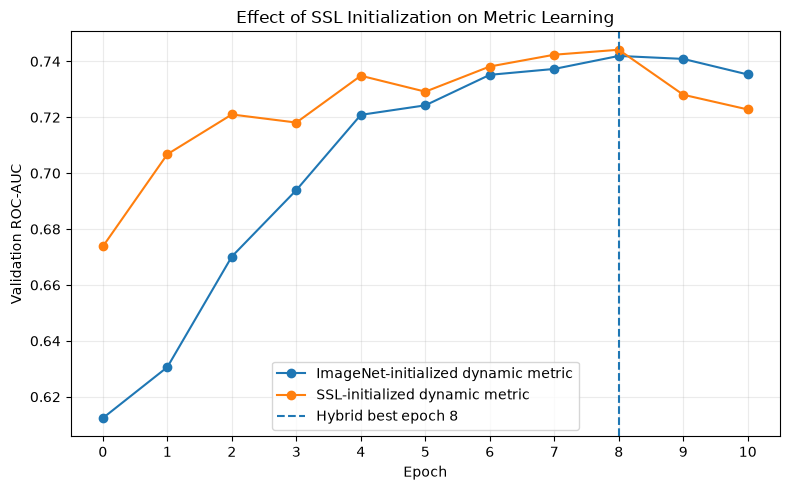

Training curve saved: True
Hybrid best epoch: 8
Validation aggregate AUC gain: 0.002212
Official-test aggregate AUC gain: 0.002853
Validation aggregate EER change: 0.2652 percentage points
Official-test aggregate EER change: -0.2932 percentage points
Condition AUC improvements: 12 of 12
Condition EER improvements: 10 of 12


In [13]:
DYNAMIC_HISTORY_PATH = (
    PROJECT_ROOT
    / "reports"
    / "writer_aware_dynamic_sampling"
    / "training_history.csv"
)

dynamic_history_df = pd.read_csv(
    DYNAMIC_HISTORY_PATH
)

fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)

ax.plot(
    dynamic_history_df[
        "epoch"
    ],
    dynamic_history_df[
        "validation_roc_auc"
    ],
    marker="o",
    label="ImageNet-initialized dynamic metric",
)

ax.plot(
    training_history_df[
        "epoch"
    ],
    training_history_df[
        "validation_roc_auc"
    ],
    marker="o",
    label="SSL-initialized dynamic metric",
)

ax.axvline(
    best_epoch,
    linestyle="--",
    label=f"Hybrid best epoch {best_epoch}",
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Validation ROC-AUC"
)

ax.set_title(
    "Effect of SSL Initialization on Metric Learning"
)

ax.set_xticks(
    range(
        0,
        EPOCHS + 1,
    )
)

ax.grid(
    alpha=0.25
)

ax.legend()

fig.tight_layout()

TRAINING_CURVE_PATH = (
    REPORT_DIR
    / "ssl_vs_imagenet_metric_training_curve.png"
)

fig.savefig(
    TRAINING_CURVE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

aggregate_rows = (
    hybrid_dynamic_comparison_df[
        hybrid_dynamic_comparison_df[
            "condition_id"
        ] == "all_conditions"
    ]
)

validation_aggregate = (
    aggregate_rows[
        aggregate_rows[
            "experiment_split"
        ] == "validation"
    ].iloc[0]
)

test_aggregate = (
    aggregate_rows[
        aggregate_rows[
            "experiment_split"
        ] == "official_test"
    ].iloc[0]
)

print(
    "Training curve saved:",
    TRAINING_CURVE_PATH.exists(),
)

print(
    "Hybrid best epoch:",
    best_epoch,
)

print(
    "Validation aggregate AUC gain:",
    round(
        validation_aggregate[
            "auc_change"
        ],
        6,
    ),
)

print(
    "Official-test aggregate AUC gain:",
    round(
        test_aggregate[
            "auc_change"
        ],
        6,
    ),
)

print(
    "Validation aggregate EER change:",
    round(
        validation_aggregate[
            "eer_change_points"
        ],
        4,
    ),
    "percentage points",
)

print(
    "Official-test aggregate EER change:",
    round(
        test_aggregate[
            "eer_change_points"
        ],
        4,
    ),
    "percentage points",
)

print(
    "Condition AUC improvements:",
    int(
        (
            condition_only_df[
                "auc_change"
            ] > 0
        ).sum()
    ),
    "of 12",
)

print(
    "Condition EER improvements:",
    int(
        (
            condition_only_df[
                "eer_change_points"
            ] < 0
        ).sum()
    ),
    "of 12",
)

## SSL-initialized metric-learning conclusion

This experiment evaluated whether self-supervised handwriting pretraining provides a better initialization for supervised writer metric learning.

The supervised protocol was kept aligned with the writer-aware dynamic-sampling baseline:

- the same 226 development-training writers
- the same Arabic page-1/page-2 supervised pairs
- the same 10 deterministic negative-writer offsets
- the same number of genuine and impostor pairs per epoch
- the same ResNet-18 architecture
- the same trainable layer-4 configuration
- the same frozen earlier backbone and BatchNorm statistics
- the same CosineEmbeddingLoss
- the same optimizer hyperparameters
- the same validation-only checkpoint-selection rule

The principal representation change was initialization.

Instead of starting supervised metric learning directly from ImageNet, the model started from the epoch-20 self-supervised MoCo handwriting encoder.

### Training behavior

The hybrid model started from the standalone SSL validation ROC-AUC of 0.6738.

Supervised writer metric learning then increased validation performance substantially.

The best checkpoint occurred at epoch 8:

- Validation ROC-AUC: 0.7441
- Validation EER: 33.00%
- Official-test ROC-AUC: 0.7669
- Official-test EER: 30.88%

No optimizer steps were skipped.

After epoch 8, validation ROC-AUC declined, confirming the importance of validation-only checkpoint selection.

### Comparison with ImageNet-initialized dynamic metric learning

The previous ImageNet-initialized dynamic metric-learning model achieved:

- Validation ROC-AUC: 0.7419
- Validation EER: 32.73%
- Official-test ROC-AUC: 0.7641
- Official-test EER: 31.17%

The SSL-initialized hybrid model therefore changed aggregate performance by:

- Validation ROC-AUC: +0.0022
- Validation EER: +0.27 percentage points
- Official-test ROC-AUC: +0.0029
- Official-test EER: -0.29 percentage points

The aggregate improvement is modest and should not by itself be interpreted as decisive superiority.

However, the condition-level behavior is more consistent.

The hybrid representation improved ROC-AUC in all 12 split-condition comparisons and reduced EER in 10 of 12 comparisons.

### Within-script and cross-script behavior

On validation writers:

- Dynamic within-script macro ROC-AUC: 0.8313
- Hybrid within-script macro ROC-AUC: 0.8524
- Dynamic cross-script macro ROC-AUC: 0.7057
- Hybrid cross-script macro ROC-AUC: 0.7277
- Dynamic script gap: 0.1256
- Hybrid script gap: 0.1247

Both within-script and cross-script performance improved, while the validation script gap remained almost unchanged.

On official-test writers:

- Dynamic within-script macro ROC-AUC: 0.8571
- Hybrid within-script macro ROC-AUC: 0.8782
- Dynamic cross-script macro ROC-AUC: 0.7297
- Hybrid cross-script macro ROC-AUC: 0.7399
- Dynamic script gap: 0.1274
- Hybrid script gap: 0.1384

The hybrid model again improved both families, but the within-script gain was larger than the cross-script gain. Consequently, the official-test script gap increased.

Therefore, self-supervised initialization improves transferable writer representation but does not establish script invariance.

### Fixed-FAR operating behavior

Validation thresholds were selected independently for target FAR values of 10%, 5%, 1%, and 0.1%.

At these validation operating points, the hybrid model improved TAR at three of four targets.

The most notable validation gains occurred at stricter FAR levels:

- approximately 1% FAR: TAR increased from 0.1042 to 0.1190
- approximately 0.1% FAR: TAR increased from 0.0089 to 0.0298

When the validation-selected thresholds were transferred unchanged to the official-test split, hybrid TAR was higher at all four operating points.

However, the achieved official-test FAR was also higher at every operating point.

For example:

- validation target 1% FAR produced official-test FAR 0.0074 for the ImageNet-initialized model and 0.0112 for the SSL-initialized model
- validation target 0.1% FAR produced official-test FAR 0.00026 and 0.00080 respectively

Therefore, higher official-test TAR cannot be interpreted as a pure same-FAR improvement.

Instead, these results reveal a threshold-transfer and score-calibration difference between the two representations.

This behavior motivates a later dedicated calibration and open-set rejection analysis.

### Main finding

The controlled experiment supports the conclusion that self-supervised handwriting pretraining is a useful initialization for writer-supervised metric learning.

Its strongest evidence is not the small aggregate AUC gain, but the fact that ROC-AUC improved across all 12 verification-condition comparisons.

At the same time:

- the gain is currently based on a single deterministic training seed
- the aggregate validation improvement is small
- script invariance has not been achieved
- threshold calibration differs between representations
- official-test results remain descriptive rather than model-selection evidence

The next major question should therefore move from representation accuracy alone to explicit measurement of what information the embedding contains.

A natural next stage is script/content leakage analysis using frozen embeddings and controlled probes before introducing an explicit script-invariant objective.

In [14]:
TRAINING_HISTORY_PATH = (
    REPORT_DIR
    / "training_history.csv"
)

PAIR_SCHEDULE_PATH = (
    REPORT_DIR
    / "dynamic_training_pair_schedule.csv"
)

CONDITION_RESULTS_PATH = (
    REPORT_DIR
    / "verification_condition_results.csv"
)

DYNAMIC_COMPARISON_PATH = (
    REPORT_DIR
    / "dynamic_hybrid_condition_comparison.csv"
)

SCRIPT_FAMILY_PATH = (
    REPORT_DIR
    / "script_family_comparison.csv"
)

OPERATING_POINTS_PATH = (
    REPORT_DIR
    / "fixed_far_operating_points.csv"
)

FAR_COMPARISON_PATH = (
    REPORT_DIR
    / "fixed_far_dynamic_hybrid_comparison.csv"
)

REPRESENTATION_COMPARISON_PATH = (
    REPORT_DIR
    / "representation_comparison.csv"
)

SUMMARY_PATH = (
    REPORT_DIR
    / "ssl_initialized_metric_summary.json"
)

training_history_df.to_csv(
    TRAINING_HISTORY_PATH,
    index=False,
)

dynamic_training_pairs_df.to_csv(
    PAIR_SCHEDULE_PATH,
    index=False,
)

hybrid_condition_results_df.to_csv(
    CONDITION_RESULTS_PATH,
    index=False,
)

hybrid_dynamic_comparison_df.to_csv(
    DYNAMIC_COMPARISON_PATH,
    index=False,
)

script_family_comparison_df.to_csv(
    SCRIPT_FAMILY_PATH,
    index=False,
)

operating_comparison_df.to_csv(
    OPERATING_POINTS_PATH,
    index=False,
)

far_gain_df.to_csv(
    FAR_COMPARISON_PATH,
    index=False,
)

representation_comparison_df = pd.DataFrame(
    [
        {
            "experiment_split": "validation",
            "representation": "imagenet_initialization",
            "roc_auc": 0.612379,
            "eer_percent": 43.1548,
        },
        {
            "experiment_split": "validation",
            "representation": "self_supervised_moco",
            "roc_auc": 0.673769,
            "eer_percent": 38.9881,
        },
        {
            "experiment_split": "validation",
            "representation": "imagenet_initialized_dynamic_metric",
            "roc_auc": 0.741935,
            "eer_percent": 32.7327,
        },
        {
            "experiment_split": "validation",
            "representation": "ssl_initialized_dynamic_metric",
            "roc_auc": frozen_validation_metrics[
                "roc_auc"
            ],
            "eer_percent": frozen_validation_metrics[
                "eer_percent"
            ],
        },
        {
            "experiment_split": "official_test",
            "representation": "imagenet_initialization",
            "roc_auc": 0.6353,
            "eer_percent": 40.1734,
        },
        {
            "experiment_split": "official_test",
            "representation": "self_supervised_moco",
            "roc_auc": 0.692327,
            "eer_percent": 36.3558,
        },
        {
            "experiment_split": "official_test",
            "representation": "imagenet_initialized_dynamic_metric",
            "roc_auc": 0.764084,
            "eer_percent": 31.1744,
        },
        {
            "experiment_split": "official_test",
            "representation": "ssl_initialized_dynamic_metric",
            "roc_auc": test_metrics[
                "roc_auc"
            ],
            "eer_percent": test_metrics[
                "eer_percent"
            ],
        },
    ]
)

representation_comparison_df.to_csv(
    REPRESENTATION_COMPARISON_PATH,
    index=False,
)

validation_family_rows = (
    script_family_comparison_df[
        script_family_comparison_df[
            "experiment_split"
        ] == "validation"
    ]
)

test_family_rows = (
    script_family_comparison_df[
        script_family_comparison_df[
            "experiment_split"
        ] == "official_test"
    ]
)

validation_within = (
    validation_family_rows[
        validation_family_rows[
            "script_family"
        ] == "within_script"
    ].iloc[0]
)

validation_cross = (
    validation_family_rows[
        validation_family_rows[
            "script_family"
        ] == "cross_script"
    ].iloc[0]
)

test_within = (
    test_family_rows[
        test_family_rows[
            "script_family"
        ] == "within_script"
    ].iloc[0]
)

test_cross = (
    test_family_rows[
        test_family_rows[
            "script_family"
        ] == "cross_script"
    ].iloc[0]
)

validation_dynamic_gap = float(
    validation_within[
        "dynamic_auc"
    ]
    - validation_cross[
        "dynamic_auc"
    ]
)

validation_hybrid_gap = float(
    validation_within[
        "hybrid_auc"
    ]
    - validation_cross[
        "hybrid_auc"
    ]
)

test_dynamic_gap = float(
    test_within[
        "dynamic_auc"
    ]
    - test_cross[
        "dynamic_auc"
    ]
)

test_hybrid_gap = float(
    test_within[
        "hybrid_auc"
    ]
    - test_cross[
        "hybrid_auc"
    ]
)

summary = {
    "initialization": {
        "source": "self_supervised_moco",
        "source_epoch": int(
            ssl_checkpoint[
                "epoch"
            ]
        ),
        "epoch0_validation_auc": float(
            epoch0_metrics[
                "roc_auc"
            ]
        ),
    },
    "training": {
        "epochs": EPOCHS,
        "best_epoch": int(
            best_epoch
        ),
        "negative_writers_per_anchor": 10,
        "epoch_offsets": (
            epoch_offsets.tolist()
        ),
        "skipped_optimizer_steps": int(
            training_history_df[
                "skipped_steps"
            ].sum()
        ),
    },
    "validation": {
        "roc_auc": float(
            frozen_validation_metrics[
                "roc_auc"
            ]
        ),
        "eer_percent": float(
            frozen_validation_metrics[
                "eer_percent"
            ]
        ),
        "auc_gain_vs_dynamic": float(
            validation_aggregate[
                "auc_change"
            ]
        ),
        "eer_change_points_vs_dynamic": float(
            validation_aggregate[
                "eer_change_points"
            ]
        ),
        "dynamic_script_gap": (
            validation_dynamic_gap
        ),
        "hybrid_script_gap": (
            validation_hybrid_gap
        ),
    },
    "official_test_descriptive": {
        "roc_auc": float(
            test_metrics[
                "roc_auc"
            ]
        ),
        "eer_percent": float(
            test_metrics[
                "eer_percent"
            ]
        ),
        "auc_gain_vs_dynamic": float(
            test_aggregate[
                "auc_change"
            ]
        ),
        "eer_change_points_vs_dynamic": float(
            test_aggregate[
                "eer_change_points"
            ]
        ),
        "dynamic_script_gap": (
            test_dynamic_gap
        ),
        "hybrid_script_gap": (
            test_hybrid_gap
        ),
    },
    "condition_comparison": {
        "auc_improved": int(
            (
                condition_only_df[
                    "auc_change"
                ] > 0
            ).sum()
        ),
        "eer_improved": int(
            (
                condition_only_df[
                    "eer_change_points"
                ] < 0
            ).sum()
        ),
        "total": int(
            len(
                condition_only_df
            )
        ),
    },
    "fixed_far": {
        "validation_tar_improved_targets": int(
            (
                far_gain_df[
                    "validation_tar_change"
                ] > 0
            ).sum()
        ),
        "official_test_tar_improved_targets": int(
            (
                far_gain_df[
                    "official_test_tar_change"
                ] > 0
            ).sum()
        ),
        "official_test_far_higher_targets": int(
            (
                far_gain_df[
                    "official_test_far_change"
                ] > 0
            ).sum()
        ),
    },
    "interpretation": {
        "ssl_initialization_improves_all_condition_auc": True,
        "script_invariance_established": False,
        "official_test_used_for_selection": False,
        "single_seed_result": True,
        "next_stage": (
            "script_and_content_leakage_analysis"
        ),
    },
}

with SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        summary,
        file,
        indent=2,
    )

saved_paths = [
    TRAINING_HISTORY_PATH,
    PAIR_SCHEDULE_PATH,
    CONDITION_RESULTS_PATH,
    DYNAMIC_COMPARISON_PATH,
    SCRIPT_FAMILY_PATH,
    OPERATING_POINTS_PATH,
    FAR_COMPARISON_PATH,
    REPRESENTATION_COMPARISON_PATH,
    SUMMARY_PATH,
    TRAINING_CURVE_PATH,
]

for path in saved_paths:
    print(
        path.name,
        ":",
        path.exists(),
    )

print()

print(
    "Best hybrid epoch:",
    best_epoch,
)

print(
    "Validation ROC-AUC:",
    round(
        frozen_validation_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Official-test ROC-AUC:",
    round(
        test_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Condition AUC improvements:",
    summary[
        "condition_comparison"
    ][
        "auc_improved"
    ],
    "of 12",
)

print(
    "Validation dynamic → hybrid script gap:",
    round(
        validation_dynamic_gap,
        4,
    ),
    "→",
    round(
        validation_hybrid_gap,
        4,
    ),
)

print(
    "Official-test dynamic → hybrid script gap:",
    round(
        test_dynamic_gap,
        4,
    ),
    "→",
    round(
        test_hybrid_gap,
        4,
    ),
)

print(
    "Validation TAR-improved FAR targets:",
    summary[
        "fixed_far"
    ][
        "validation_tar_improved_targets"
    ],
    "of 4",
)

print(
    "Official-test thresholds with higher FAR:",
    summary[
        "fixed_far"
    ][
        "official_test_far_higher_targets"
    ],
    "of 4",
)

print(
    "Script invariance established:",
    summary[
        "interpretation"
    ][
        "script_invariance_established"
    ],
)

print(
    "Notebook 14 complete:",
    True,
)

assert all(
    path.exists()
    for path in saved_paths
)

training_history.csv : True
dynamic_training_pair_schedule.csv : True
verification_condition_results.csv : True
dynamic_hybrid_condition_comparison.csv : True
script_family_comparison.csv : True
fixed_far_operating_points.csv : True
fixed_far_dynamic_hybrid_comparison.csv : True
representation_comparison.csv : True
ssl_initialized_metric_summary.json : True
ssl_vs_imagenet_metric_training_curve.png : True

Best hybrid epoch: 8
Validation ROC-AUC: 0.744147
Official-test ROC-AUC: 0.766937
Condition AUC improvements: 12 of 12
Validation dynamic → hybrid script gap: 0.1256 → 0.1247
Official-test dynamic → hybrid script gap: 0.1274 → 0.1384
Validation TAR-improved FAR targets: 3 of 4
Official-test thresholds with higher FAR: 4 of 4
Script invariance established: False
Notebook 14 complete: True
